In [1]:
from roctet import calc_roctet
from roctet.utils import auroc
from numpy import arange
import polars as pl
import polars.selectors as cs
import polars_ds as pds
from plotnine import (
    ggplot,
    aes,
    geom_line,
    geom_abline,
    geom_density,
    facet_grid,
    labs,
    theme_set,
    theme_bw,
    theme,
)

In [2]:
theme_set(theme_bw())

## Data Generation

In [3]:
# generate datasets
dfs_beta = calc_roctet(0.67, method="beta", n_sets=10, n_obsv = 1e5)  
dfs_pcws = calc_roctet(0.67, method="piecewise", n_sets=10, n_obsv = 1e5)
dfs_beta[0].glimpse()

Rows: 100000
Columns: 4
$ score  <f64> 0.9996820338971453, 0.9990528738926949, 0.9992195794522248, 0.9991835553660647, 0.9991750809820671, 0.9998119064130688, 0.9999232682662933, 0.9992758502480452, 0.9998195741357288, 0.9998897824755868
$ target <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ id     <i32> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
$ method <str> 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta'



In [4]:
# consolidate to one dataset
df = pl.concat(
    [d.with_columns(method=pl.lit("beta")) for d in dfs_beta] +
    [d.with_columns(method=pl.lit("piecewise")) for d in dfs_pcws]
)
df.glimpse()

Rows: 2000000
Columns: 4
$ score  <f64> 0.9996820338971453, 0.9990528738926949, 0.9992195794522248, 0.9991835553660647, 0.9991750809820671, 0.9998119064130688, 0.9999232682662933, 0.9992758502480452, 0.9998195741357288, 0.9998897824755868
$ target <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ id     <i32> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
$ method <str> 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta', 'beta'



## ROC Summary

In [5]:
# compare AUC values
aucs = [
    auroc(d["target"].to_numpy(), d["score"].to_numpy()) for d in dfs_beta + dfs_pcws
]
print(aucs)
print(f"Max Diff: {max(aucs) - min(aucs)}")

[0.67, 0.6697, 0.6688, 0.6689, 0.6714, 0.6717, 0.671, 0.6699, 0.6689, 0.6701, 0.6719, 0.6711, 0.6689, 0.6685, 0.6694, 0.6681, 0.6683, 0.6696, 0.6687, 0.6685]
Max Diff: 0.0038000000000000256


## ROC Curves

C:\Users\emily\Desktop\roctet\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
C:\Users\emily\Desktop\roctet\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: aucs.png


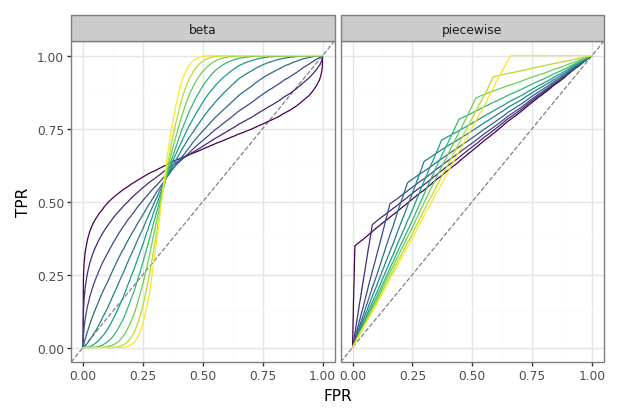

In [6]:
# compute and display roc curve
df_roc = (
    df.sort("score", descending=True)
    .with_columns(
        neg_target=1 - pl.col("target"),
        neg_target_ttl=(1 - pl.col("target")).sum().over("id", "method"),
        pos_target=pl.col("target"),
        pos_target_ttl=pl.col("target").sum().over("id", "method"),
    )
    .with_columns(
        cum_fpr=pl.col("neg_target").cum_sum().over("id", "method")
        / pl.col("neg_target_ttl"),
        cum_tpr=pl.col("pos_target").cum_sum().over("id", "method")
        / pl.col("pos_target_ttl"),
    )
)

p = ggplot(df_roc)
p += aes(x="cum_fpr", y="cum_tpr", color="id", group="id")
p += geom_abline(intercept=0, slope=1, color="grey", linetype="dashed")
p += geom_line()
p += facet_grid(cols="method")
p += theme(legend_position="none", figure_size=(6,4))
p += labs(x="FPR", y="TPR")
p.save("aucs.png")
p

## Metrics

In [7]:
df_metrics = (
    df.group_by("method", "id")
    .agg(metrics=pds.query_binary_metrics("target", "score", 0.5))
    .unnest("metrics")
)
df_metrics

method,id,precision,recall,f,avg_precision,roc_auc
str,i32,f64,f64,f64,f64,f64
"""piecewise""",3,0.589536,0.718953,0.647845,0.6518,0.668542
"""beta""",0,0.577889,0.679511,0.624593,0.768178,0.669964
"""beta""",7,0.652675,0.947804,0.773029,0.54451,0.669875
"""piecewise""",5,0.605517,0.769138,0.67759,0.627555,0.668072
"""beta""",8,0.659299,0.982418,0.789061,0.539484,0.668891
…,…,…,…,…,…,…
"""beta""",4,0.610693,0.786407,0.6875,0.594456,0.671409
"""beta""",3,0.597809,0.741542,0.661963,0.642299,0.668905
"""piecewise""",9,0.599704,0.756531,0.66905,0.598817,0.668536


In [10]:
(
    df_metrics.drop("method", "id")
    .select(
        cs.all().std().name.prefix("std__"),
        (cs.all().max() - cs.all().min()).name.prefix("rng__"),
    )
    .unpivot()
    .with_columns(pl.col("variable").str.split_exact("__", 1))
    .unnest("variable")
    .pivot(index="field_1", on="field_0")
)

field_1,std,rng
str,f64,f64
"""precision""",0.027568,0.086647
"""recall""",0.100716,0.324125
"""f""",0.055073,0.17564
"""avg_precision""",0.069464,0.228694
"""roc_auc""",0.001193,0.003839


## Lift Charts

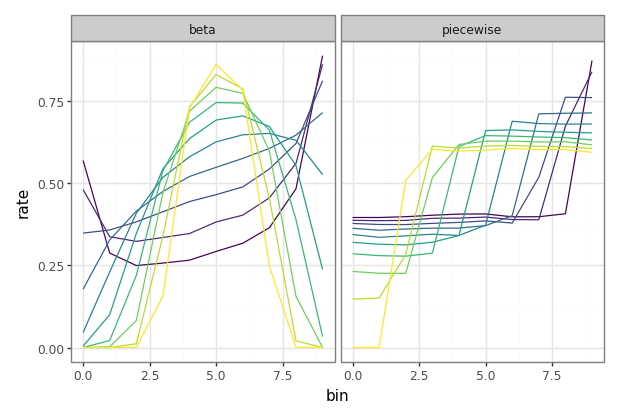

In [11]:
# visualize lift curves
df_lift = df.group_by(
    "method",
    "id",
    bin=pl.col("score")
    .qcut(10, labels=arange(10).astype(str))
    .cast(pl.String)
    .cast(pl.Int16),
).agg(rate=pl.col("target").mean())

p = ggplot(df_lift)
p += aes(x="bin", y="rate", color="id", group="id")
p += geom_line()
p += facet_grid(cols="method")
p += theme(legend_position="none", figure_size=(6,4))
p

## Score Distribution

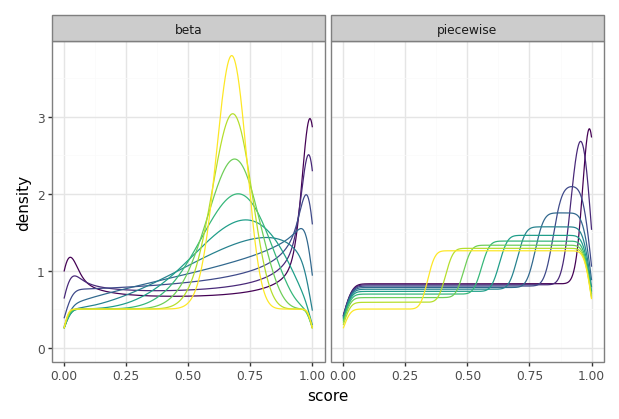

In [12]:
# visualize lift curves
df_lift = df.group_by(
    "method",
    "id",
    bin=pl.col("score")
    .qcut(10, labels=arange(10).astype(str))
    .cast(pl.String)
    .cast(pl.Int16),
).agg(rate=pl.col("target").mean())

p = ggplot(df)
p += aes(x="score", color="id", group="id")
p += geom_density()
p += facet_grid(cols="method")
p += theme(legend_position="none", figure_size=(6,4))
p